/tmp/ipykernel_1759/2078743089.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_pct.index, y=churn_pct.values, ax=axes[0], palette="Set2")


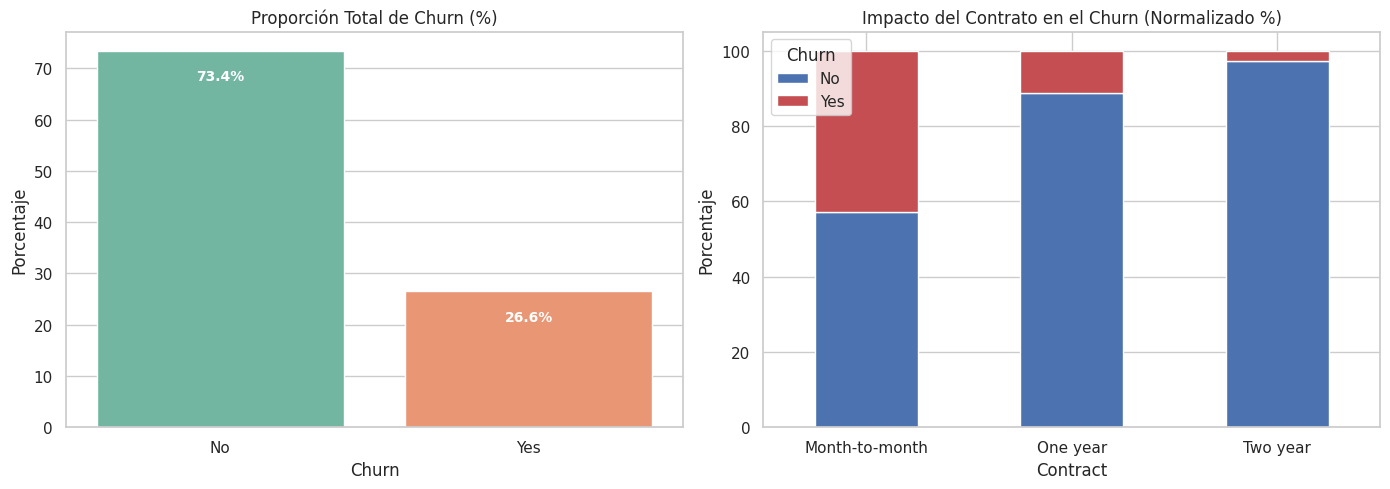

In [1]:
#1. Análisis de Distribución Relativa (Evita la trampa del conteo)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../01.data/processed/telco_churn_clean.csv")

# Configurar estilo visual limpio y profesional
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 12, 'figure.titlesize': 14})

# Crear cuadrícula para optimizar espacio (2 gráficos en 1 fila)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución Porcentual del Churn
churn_pct = df["Churn"].value_counts(normalize=True) * 100
sns.barplot(x=churn_pct.index, y=churn_pct.values, ax=axes[0], palette="Set2")
axes[0].set_title("Proporción Total de Churn (%)")
axes[0].set_ylabel("Porcentaje")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                ha='center', va='center', color='white', fontweight='bold')

# 2. Tasa de Churn Normalizada por Tipo de Contrato
# (Muestra la tasa real dentro de cada contrato, no el conteo bruto)
contract_churn = df.groupby("Contract")["Churn"].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind="bar", stacked=True, ax=axes[1], color=["#4c72b0", "#c44e52"])
axes[1].set_title("Impacto del Contrato en el Churn (Normalizado %)")
axes[1].set_ylabel("Porcentaje")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1759/2293431318.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=["object"]).columns:


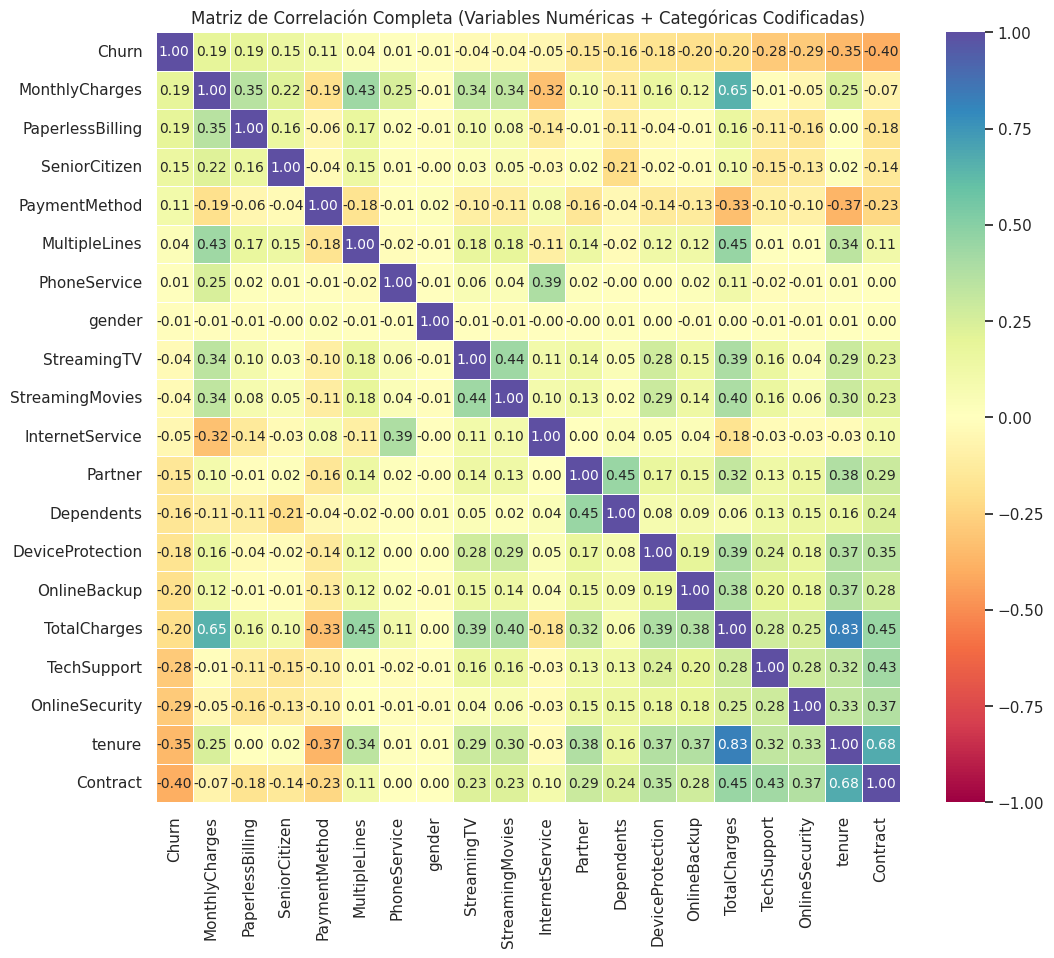

In [2]:
#2. Matriz de Correlación para Variables Categóricas (Cramer's V)
import numpy as np

# Creamos una copia para el mapa de correlación transformando variables de texto a numéricas discretas
df_encoded = df.copy().drop(columns=["customerID"])

for col in df_encoded.select_dtypes(include=["object"]).columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

# Calculamos la correlación completa (Pearson extendido a categorías codificadas)
plt.figure(figsize=(12, 10))

# Seleccionamos las variables con mayor correlación con Churn para no saturar la vista
top_corr = df_encoded.corr()["Churn"].sort_values(ascending=False).index

sns.heatmap(
    df_encoded[top_corr].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="Spectral", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

plt.title("Matriz de Correlación Completa (Variables Numéricas + Categóricas Codificadas)")
plt.show()

/tmp/ipykernel_1759/254837435.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="muted")


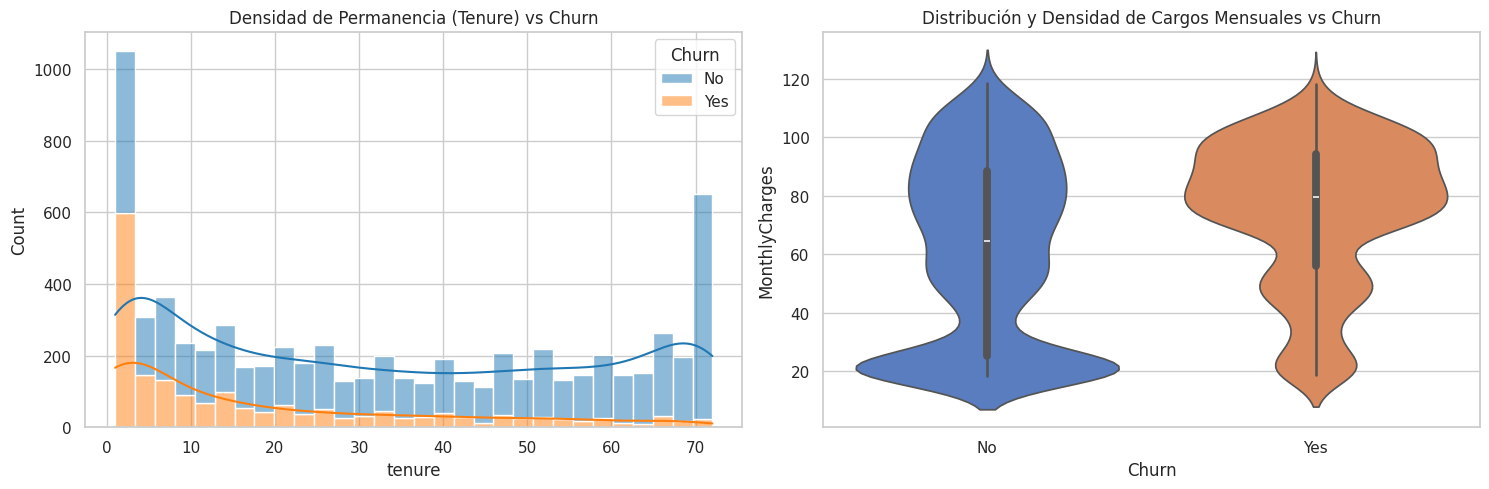

In [3]:
#3. Análisis de Comportamiento Financiero y Permanencia
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de Tenure con estimación de densidad kernel (KDE) por clase
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, bins=30, ax=axes[0], multiple="stack", palette="tab10")
axes[0].set_title("Densidad de Permanencia (Tenure) vs Churn")

# Relación de Cargos Mensuales con violines (Aporta más información de densidad que el boxplot estándar)
sns.violinplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="muted")
axes[1].set_title("Distribución y Densidad de Cargos Mensuales vs Churn")

plt.tight_layout()
plt.show()